In [1]:
import numpy as np
import pandas as pd

from experiments import utils
from package_name.training.utils import sampling
from package_name.training.vae import VAE, VAEConfig

## Parameters

In [2]:
g0 = 9.80665
extended_winter_months = [11, 12, 1, 2, 3]
filepath = "results/cmmvae/"
cluster_number = 7
original_dim = 825
pr_cluster_number = 5
batch_size = 128
epochs = 150


## Data pre-processing

In [3]:
# Get training data
z500 = utils.preprocess_dataset(filename ='data/era5_z500_daily_250_atlantic_1940_2022.nc',
                             variable_name = 'z',
                             multiplication_factor = 1/g0,
                             geographical_filter = 'new atlantic',
                             months_filter = extended_winter_months,
                             anomalies = True,
                             normalization = False,
                             rolling_window = 5)

z500 = z500.where(z500['time.year'] > 1980, drop=True)
z500 = z500.where(z500['time.year'] < 2023, drop=True)


weights = np.cos(np.deg2rad(z500.latitude))
z500 = z500*weights
z500 = z500/z500.std()

z500_reshaped = utils.reshape_data_for_clustering(z500)

# Get training data labels
pr_labels = pd.read_csv('data/CHIRPS_pr_cluster_labels_5.csv')
pr_labels.columns = ['index', 'labels']
pr_labels.drop(pr_labels.tail(1).index,inplace=True)

pr_labels['values']=[1]*len(pr_labels)
label_indices_pd = pd.pivot_table(pr_labels, values='values', index=['index'],
                    columns=['labels'], aggfunc=np.sum).fillna(0)
label_indices = label_indices_pd.values

## Define model

In [4]:
config = VAEConfig(
    original_dim=original_dim,
    original_dim_r=pr_cluster_number,
    dim_layer1=256,
    dim_layer2=128,
    dim_layer3=64,
    activation="relu",
    cluster_number=cluster_number,
    latent_dim=15,
    pr_cluster_number=pr_cluster_number,
    sampling_fn=sampling,
)

vae = VAE(cfg=config,  path_for_weights_initialization=filepath)
vae.compile()
history = vae.fit(
    X=z500.values,
    y=label_indices,
    epochs=epochs,
    batch_size=batch_size
)

Epoch 1/150
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 367.0762 - val_loss: 254.6036
Epoch 2/150
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 199.2626 - val_loss: 164.6839
Epoch 3/150
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 148.1318 - val_loss: 136.1458
Epoch 4/150
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 131.4655 - val_loss: 128.1924
Epoch 5/150
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 121.4236 - val_loss: 116.4619
Epoch 6/150
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 108.3107 - val_loss: 104.2801
Epoch 7/150
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 99.0540 - val_loss: 95.6557
Epoch 8/150
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 92.8473 - val_loss: 90.9948
Epoch 9/150
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 87.9600 - val_loss: 87.7378
Epoch 10/150
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 85.1484 - val_loss: 85.6736
Epoch 11/150
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 83.0937 - val_loss: 85.7473
Epoch 12/150
35/35 ━━━━━━━━━━

## Plot training and validation losses.

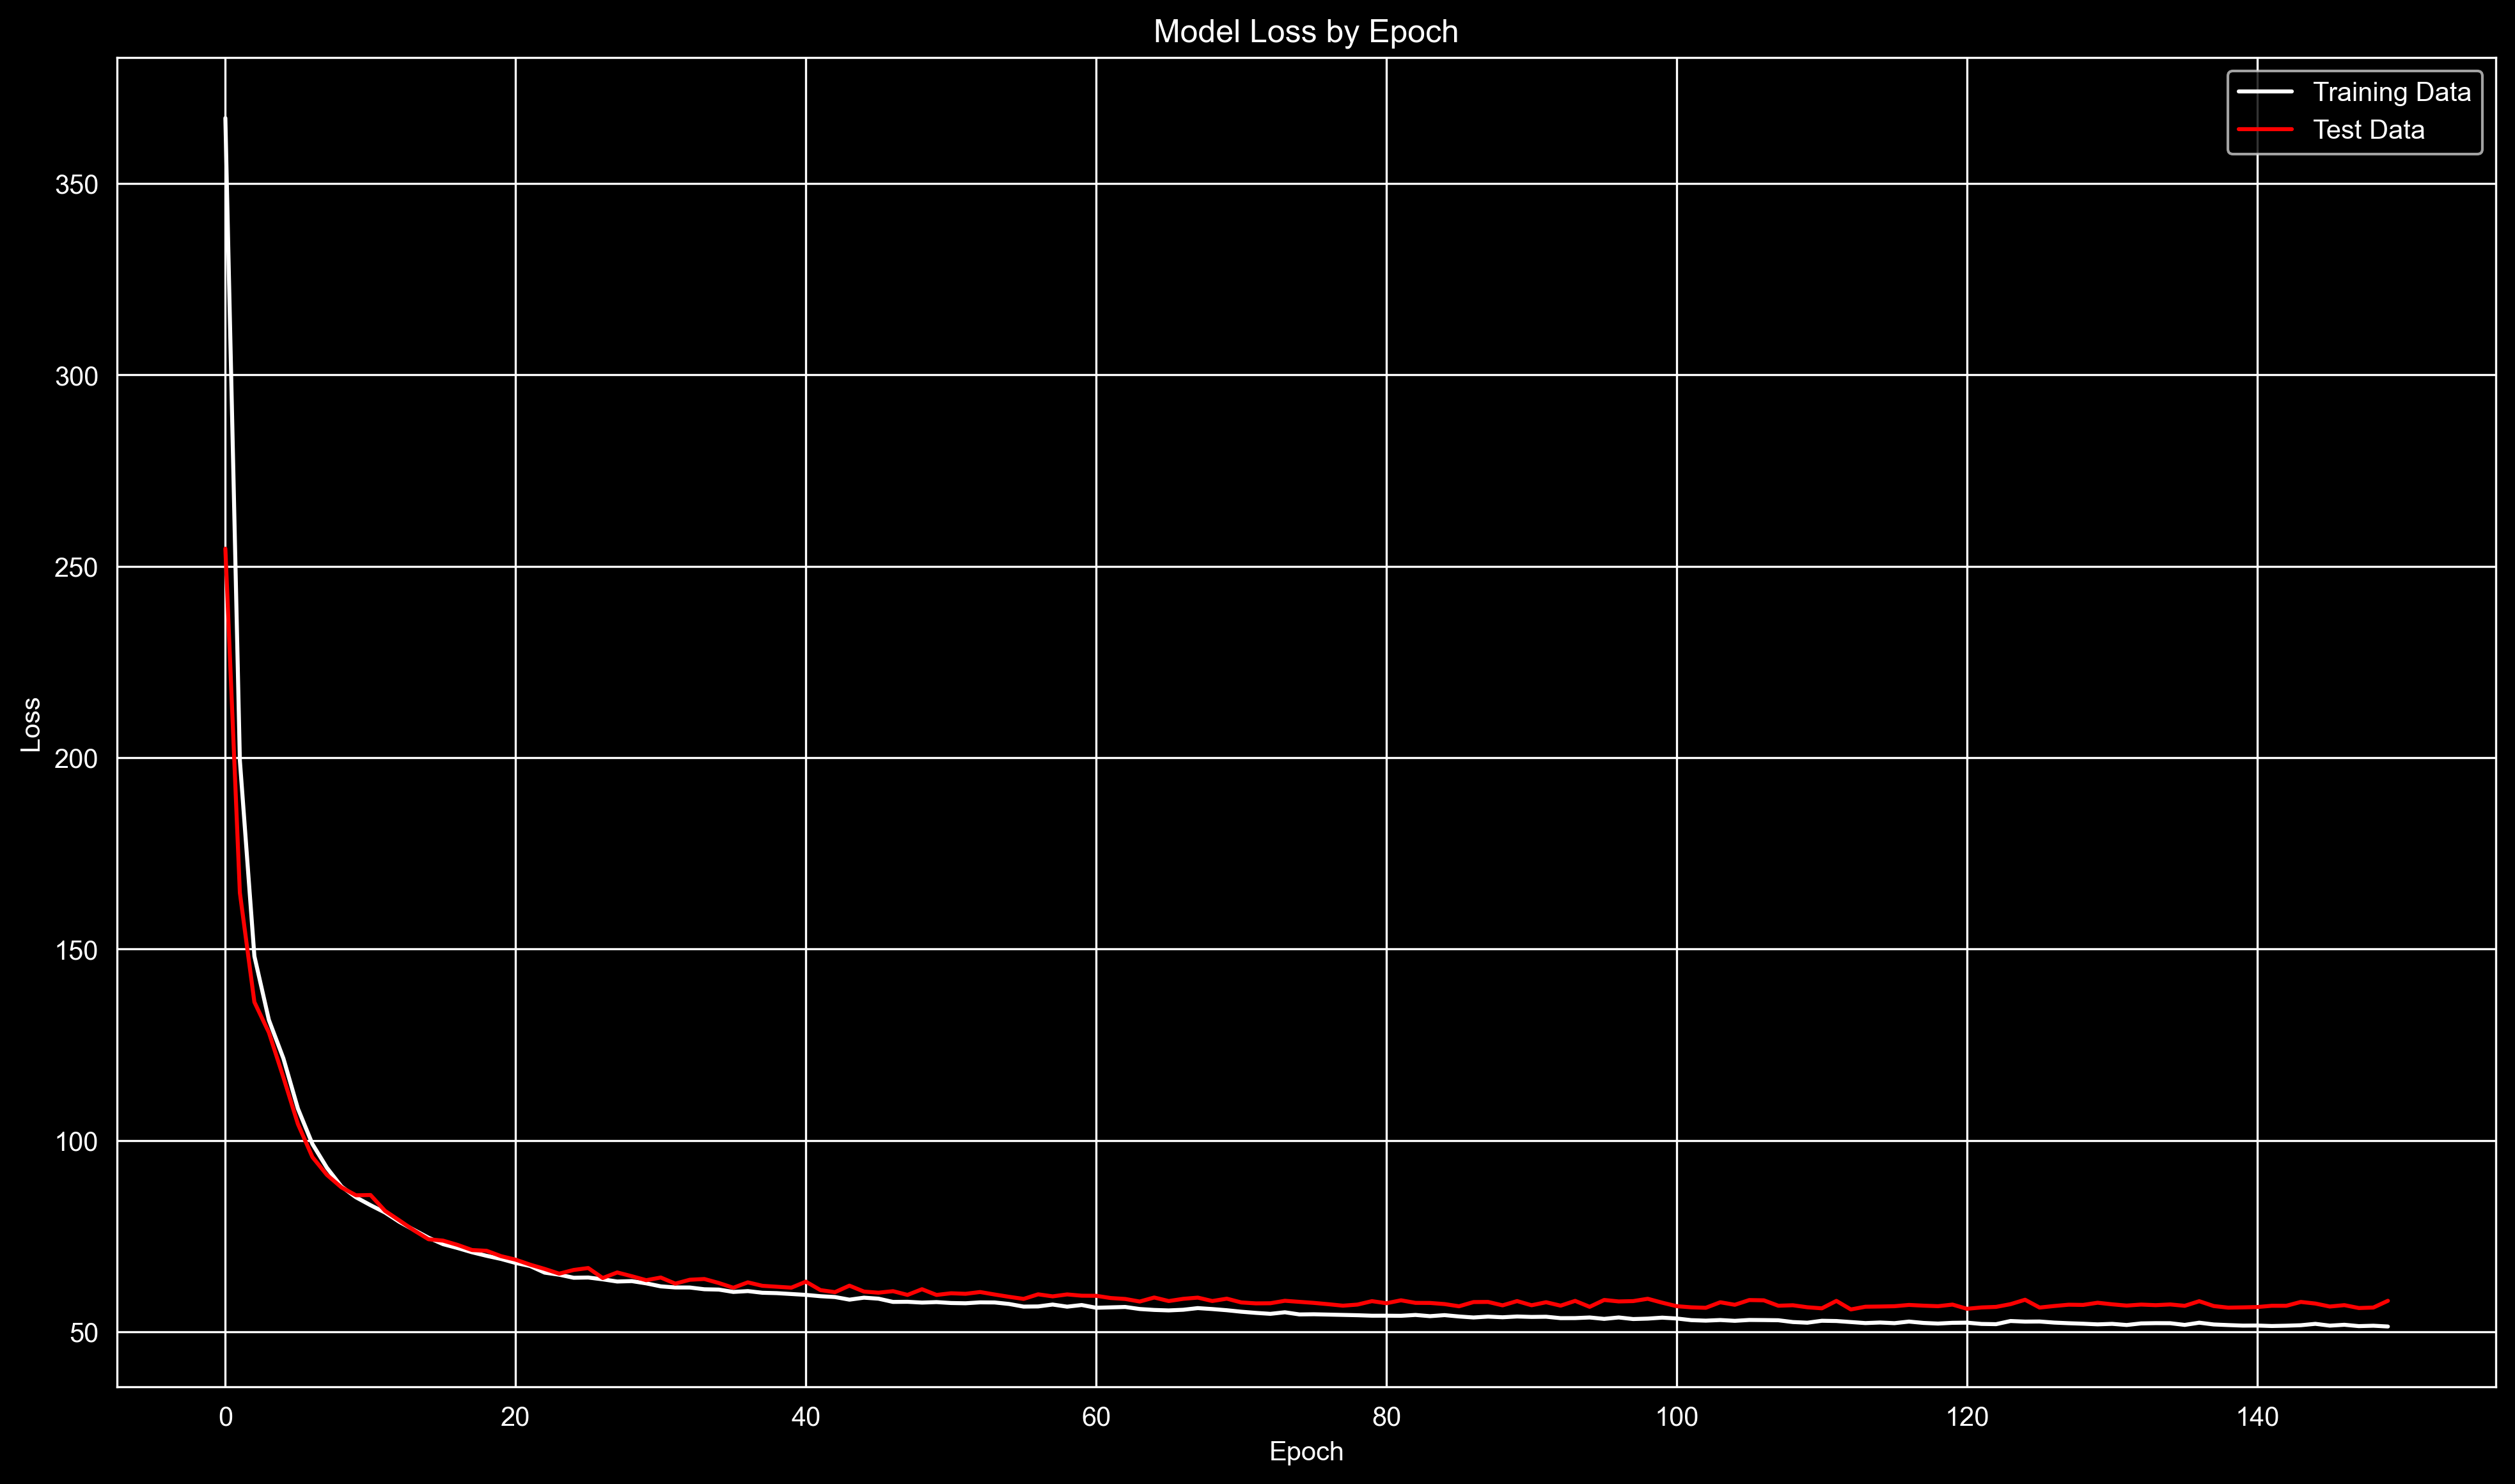

In [5]:
training_loss = history.history['loss']
validation_loss = history.history['val_loss']
utils.plot_losses(training_loss, validation_loss)

## Cross validation